# Eficiencia Hospitalaria en Chile — REM 20 MINSAL
## Segundo Avance de Proyecto — Análisis de Datos e Inferencia Estadística
**Universidad del Desarrollo – Facultad de Ingeniería**

| Campo | Detalle |
|-------|---------|
| **Dataset** | Indicadores REM 20 — MINSAL (datos.gob.cl) |
| **Período** | 2014 – 2025 |
| **Integrantes** | Pablo Lineros · Valentin Castro |
| **Profesor** | Cristian Orlando García Gutiérrez |
| **Ayudante** | Benjamin Joseph Bennett Ramírez |
| **Fecha de entrega** | 11 de mayo de 2026 |

---

### Pregunta de investigación

> **¿Existen hospitales con estancias sistemáticamente más largas para diagnósticos similares, y qué factores (complejidad clínica, ocupación, rotación y pandemia) explican esas diferencias?**

### Variable dependiente
`PROMEDIO_DIAS_ESTADA` — promedio de días que un paciente permanece hospitalizado.

### Variables independientes

| Variable | Tipo | Rol en el modelo |
|----------|------|-----------------|
| `AREA_FUNCIONAL` | Categórica | Controla complejidad clínica |
| `INDICE_OCUPACIONAL` | Continua | Nivel de saturación del servicio |
| `INDICE_ROTACION` | Continua | Eficiencia en uso de camas |
| `pandemia` | Binaria (0/1) | Efecto COVID-19 (2020–2021) |

### Hipótesis
- **H₀:** La estancia promedio no difiere significativamente entre hospitales una vez controlado por área funcional, ocupación, rotación y pandemia.
- **H₁:** Al menos una variable independiente tiene un efecto significativo sobre la estancia promedio.


---
## 1. Importación de librerías


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf
import statsmodels.api as sm
import warnings

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.grid":        True,
    "grid.alpha":       0.4,
    "axes.spines.top":  False,
    "axes.spines.right": False,
    "font.size":        11,
})

---
## 2. Carga y Limpieza de Datos

### 2.1 Carga del archivo


In [2]:
df_raw = pd.read_csv("indicadores_rem20_20260225.csv", sep=";", encoding="utf-8")

print(f"Filas cargadas : {len(df_raw):,}")
print(f"Columnas       : {df_raw.shape[1]}")
print(f"Hospitales     : {df_raw['ESTABLECIMIENTO'].nunique()}")
print(f"Período        : {df_raw['PERIODO'].min()} – {df_raw['PERIODO'].max()}")

Filas cargadas : 159,788
Columnas       : 20
Hospitales     : 313
Período        : 2014 – 2025


### 2.2 Limpieza y filtros

Se aplicaron tres filtros sobre el dataset original:

1. **`NUMERO_EGRESOS > 0`**: los meses sin actividad registrada no aportan información válida sobre duración de estadías.
2. **`PROMEDIO_DIAS_ESTADA > 0`**: una estancia de cero días es clínicamente incoherente.
3. **`INDICE_OCUPACIONAL ≤ 100`**: valores superiores al 100% son errores de digitación en el sistema MINSAL. Se identificaron registros con valores de hasta 2.700%, lo que invalida cualquier análisis de regresión.

Adicionalmente, se excluyen las áreas de **Psiquiatría** y **Sociosanitaria** del subconjunto de hospitalización aguda. Estas áreas tienen estancias de meses o años por su naturaleza crónica, lo que distorsiona el análisis comparativo entre hospitales de agudos.

Para el **modelo de regresión** se excluyen además los registros por sobre el percentil 99 de `PROMEDIO_DIAS_ESTADA` (> 113 días), reduciendo el efecto de casos extremos sobre los coeficientes OLS.


In [3]:
antes = len(df_raw)
df = df_raw[
    (df_raw["NUMERO_EGRESOS"]       > 0  ) &
    (df_raw["PROMEDIO_DIAS_ESTADA"] > 0  ) &
    (df_raw["INDICE_OCUPACIONAL"]   <= 100)
].copy()

print(f"Registros originales : {antes:,}")
print(f"Registros eliminados : {antes - len(df):,}  ({(antes-len(df))/antes*100:.1f}%)")
print(f"Registros válidos    : {len(df):,}")

EXCLUIR = ["Psiquiatría", "Sociosanitaria"]
mask_excl = df["AREA_FUNCIONAL"].str.contains("|".join(EXCLUIR), na=False)
df_aguda  = df[~mask_excl].copy()
df_aguda["pandemia"] = df_aguda["PERIODO"].isin([2020, 2021]).astype(int)

print(f"\nRegistros hospitalización aguda: {len(df_aguda):,}")

p99 = df_aguda["PROMEDIO_DIAS_ESTADA"].quantile(0.99)
df_model = df_aguda[df_aguda["PROMEDIO_DIAS_ESTADA"] <= p99].copy()

top_areas = df_model["AREA_FUNCIONAL"].value_counts().head(8).index
df_model["area_cat"] = df_model["AREA_FUNCIONAL"].apply(
    lambda x: x if x in top_areas else "Otras"
)

print(f"Registros para modelo (sin P99): {len(df_model):,}")
print(f"Percentil 99 de estancia       : {p99:.1f} días")

vars_key = ["PROMEDIO_DIAS_ESTADA","INDICE_OCUPACIONAL","INDICE_ROTACION","AREA_FUNCIONAL"]
nulos = df_aguda[vars_key].isnull().sum()
print("\nValores nulos en variables clave:")
print(nulos)
print(f"\nFilas duplicadas: {df_aguda.duplicated().sum()}")

Registros originales : 159,788
Registros eliminados : 13,007  (8.1%)
Registros válidos    : 146,781

Registros hospitalización aguda: 136,196


Registros para modelo (sin P99): 134,835
Percentil 99 de estancia       : 113.0 días

Valores nulos en variables clave:
PROMEDIO_DIAS_ESTADA    0
INDICE_OCUPACIONAL      0
INDICE_ROTACION         0
AREA_FUNCIONAL          0
dtype: int64

Filas duplicadas: 0


---
## 3. Análisis Exploratorio de Datos (EDA)

### 3.1 Estadística descriptiva — variables numéricas


In [4]:
vars_num = ["PROMEDIO_DIAS_ESTADA","INDICE_OCUPACIONAL","INDICE_ROTACION","NUMERO_EGRESOS"]
desc = df_aguda[vars_num].describe().round(3)
desc.loc["CV (%)"] = (df_aguda[vars_num].std() / df_aguda[vars_num].mean() * 100).round(1)
print("Tabla 1: Estadísticos descriptivos — variables numéricas principales")
print(desc.to_string())

Tabla 1: Estadísticos descriptivos — variables numéricas principales
        PROMEDIO_DIAS_ESTADA  INDICE_OCUPACIONAL  INDICE_ROTACION  NUMERO_EGRESOS
count             136196.000          136196.000       136196.000      136196.000
mean                  12.772              64.883            3.198          85.707
std                   35.583              27.570            3.173         131.805
min                    0.090               0.000            0.000           1.000
25%                    3.220              46.548            1.290          10.000
50%                    5.930              71.770            2.670          34.000
75%                   11.290              88.100            4.300         102.000
max                 7135.500             100.000          236.380        1700.000
CV (%)               278.600              42.500           99.200         153.800


La diferencia entre la media (12.77 días) y la mediana (5.93 días) refleja una distribución con asimetría positiva marcada: la mayoría de los pacientes tienen estadías cortas, pero una cola de casos complejos eleva el promedio. Esto justifica el uso de pruebas no paramétricas para comparar grupos y la exclusión de valores extremos en el modelo de regresión.

### 3.2 Estadística descriptiva — variables categóricas


In [5]:
print("Tabla 2: Frecuencia por área funcional (top 10)")
freq_area = (df_aguda["AREA_FUNCIONAL"]
    .value_counts()
    .reset_index()
    .rename(columns={"count":"N"})
)
freq_area["%"] = (freq_area["N"] / len(df_aguda) * 100).round(2)
print(freq_area.head(10).to_string(index=False))

print()
print("Tabla 3: Registros por año")
freq_per = df_aguda["PERIODO"].value_counts().sort_index().reset_index()
freq_per.columns = ["PERIODO","N"]
freq_per["%"] = (freq_per["N"] / len(df_aguda) * 100).round(2)
freq_per["pandemia"] = freq_per["PERIODO"].isin([2020,2021]).map({True:"Sí",False:"No"})
print(freq_per.to_string(index=False))

Tabla 2: Frecuencia por área funcional (top 10)
                                     AREA_FUNCIONAL     N     %
                                  Área Obstetricia  16247 11.93
               Área Médica Adulto Cuidados Básicos  15605 11.46
           Área Médico-Quirúrgico Cuidados Básicos  14779 10.85
           Área Médica Pediátrica Cuidados Básicos  11882  8.72
                 Área Cuidados Intermedios Adultos   9466  6.95
            Área Médico-Quirúrgico Cuidados Medios   9277  6.81
                  Área Cuidados Intensivos Adultos   7687  5.64
                Área Neonatología Cuidados Básicos   7317  5.37
Área Médico-Quirúrgico Pediátrica Cuidados Básicos   6172  4.53
                Área Médica Adulto Cuidados Medios   5929  4.35

Tabla 3: Registros por año
 PERIODO     N    % pandemia
    2014 11341 8.33       No
    2015 11510 8.45       No
    2016 11521 8.46       No
    2017 11476 8.43       No
    2018 11615 8.53       No
    2019 11502 8.45       No
    2020 11291 8.

El dataset está dominado por unidades de cuidados básicos y obstetricia, lo que es coherente con la red pública chilena: la mayor volumetría de egresos ocurre en niveles de menor complejidad técnica. Los años 2020 y 2021 representan en conjunto alrededor del 16% del total de registros, proporción suficiente para comparaciones estadísticas robustas.

### 3.3 Visualizaciones exploratorias


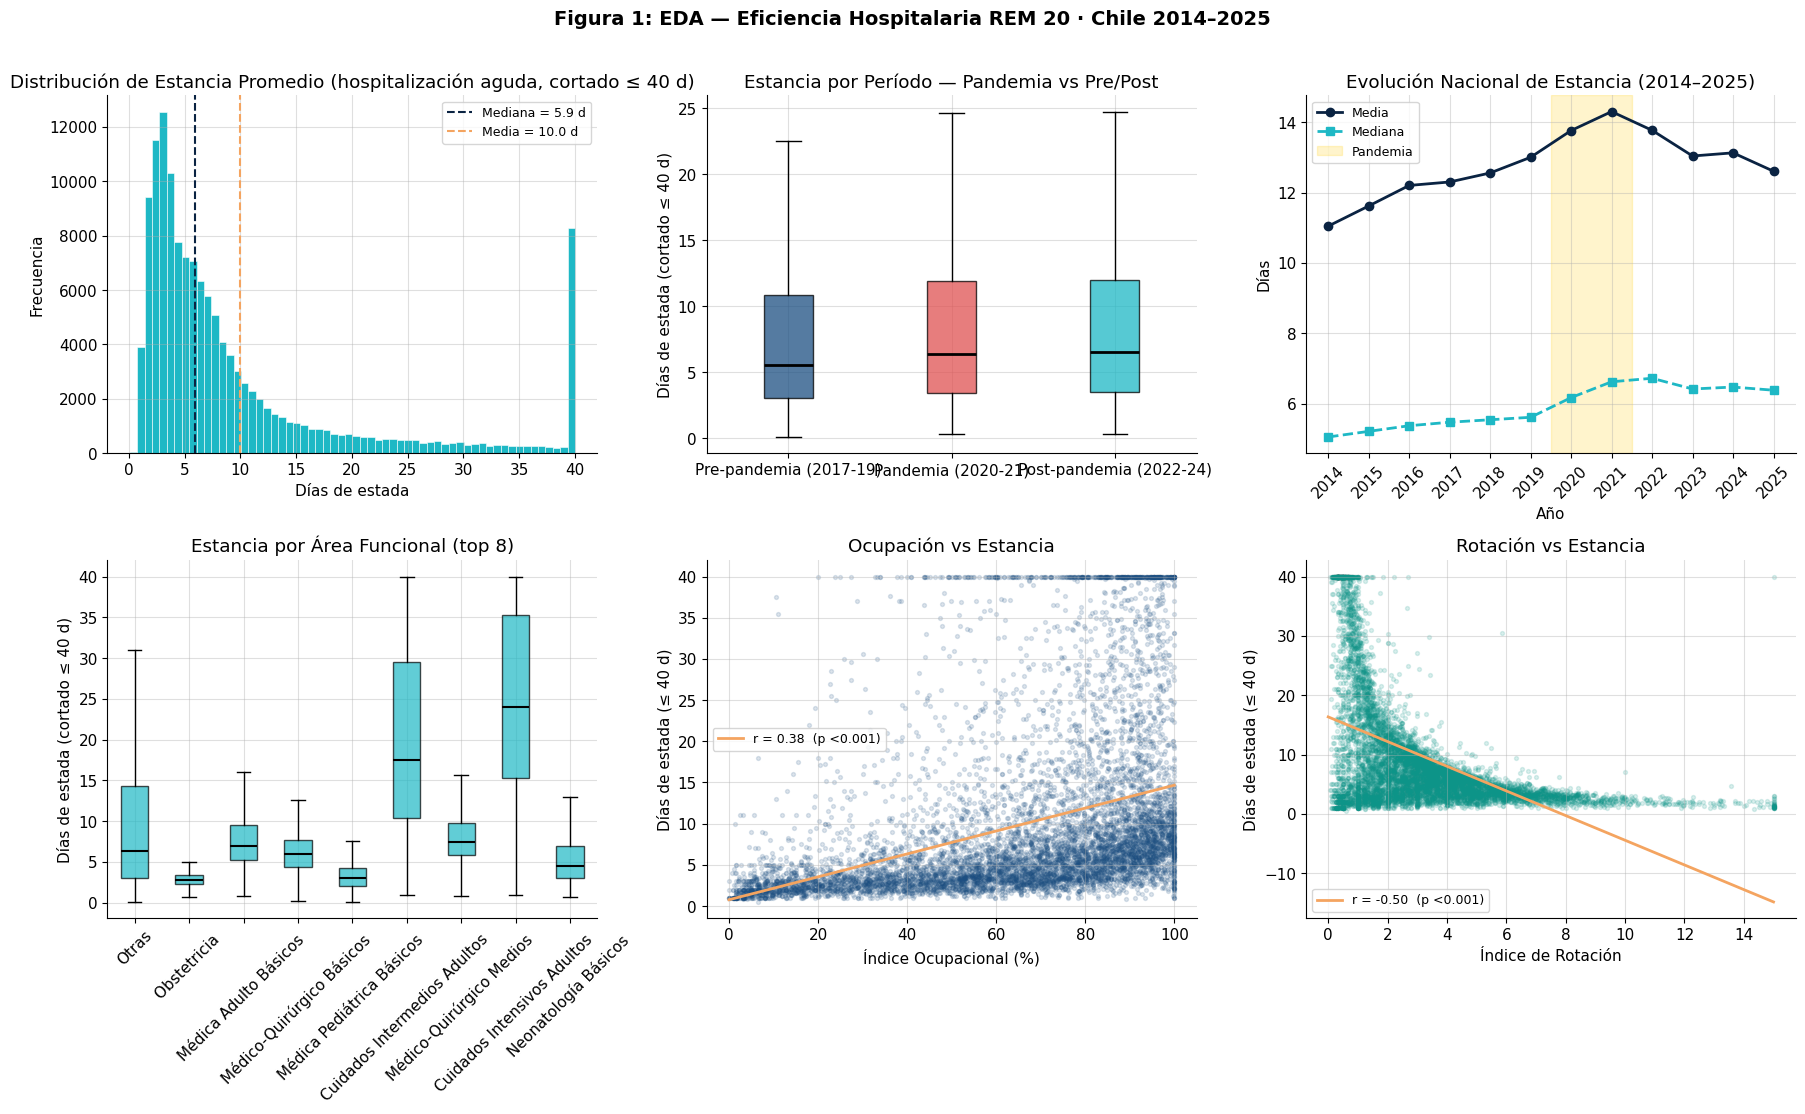

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Figura 1: EDA — Eficiencia Hospitalaria REM 20 · Chile 2014–2025",
             fontsize=14, fontweight="bold", y=1.01)

ax = axes[0, 0]
datos_h = df_aguda["PROMEDIO_DIAS_ESTADA"].clip(upper=40)
ax.hist(datos_h, bins=60, color="#1EB8C5", edgecolor="white", linewidth=0.4)
ax.axvline(datos_h.median(), color="#0A2342", ls="--", lw=1.5,
           label=f"Mediana = {datos_h.median():.1f} d")
ax.axvline(datos_h.mean(), color="#F4A460", ls="--", lw=1.5,
           label=f"Media = {datos_h.mean():.1f} d")
ax.set_title("Distribución de Estancia Promedio (hospitalización aguda, cortado ≤ 40 d)")
ax.set_xlabel("Días de estada")
ax.set_ylabel("Frecuencia")
ax.legend(fontsize=9)

ax = axes[0, 1]
pre   = df_aguda[df_aguda["PERIODO"].isin([2017,2018,2019])]["PROMEDIO_DIAS_ESTADA"].clip(upper=40)
pan   = df_aguda[df_aguda["PERIODO"].isin([2020,2021])      ]["PROMEDIO_DIAS_ESTADA"].clip(upper=40)
post  = df_aguda[df_aguda["PERIODO"].isin([2022,2023,2024]) ]["PROMEDIO_DIAS_ESTADA"].clip(upper=40)
bp = ax.boxplot([pre, pan, post],
                labels=["Pre-pandemia (2017-19)","Pandemia (2020-21)","Post-pandemia (2022-24)"],
                patch_artist=True, showfliers=False,
                medianprops=dict(color="black", linewidth=2))
for patch, c in zip(bp["boxes"], ["#1C4F82","#E05252","#1EB8C5"]):
    patch.set_facecolor(c); patch.set_alpha(0.75)
ax.set_title("Estancia por Período — Pandemia vs Pre/Post")
ax.set_ylabel("Días de estada (cortado ≤ 40 d)")

ax = axes[0, 2]
evol = df_aguda.groupby("PERIODO")["PROMEDIO_DIAS_ESTADA"].agg(media="mean", mediana="median").reset_index()
ax.plot(evol["PERIODO"], evol["media"],   marker="o", lw=2, color="#0A2342", label="Media")
ax.plot(evol["PERIODO"], evol["mediana"], marker="s", lw=2, color="#1EB8C5", ls="--", label="Mediana")
ax.axvspan(2019.5, 2021.5, color="#FFCC00", alpha=0.2, label="Pandemia")
ax.set_title("Evolución Nacional de Estancia (2014–2025)")
ax.set_xlabel("Año"); ax.set_ylabel("Días"); ax.legend(fontsize=9)
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.tick_params(axis="x", rotation=45)

ax = axes[1, 0]
top8 = df_model["area_cat"].value_counts().index.tolist()
data_area = [df_model[df_model["area_cat"]==a]["PROMEDIO_DIAS_ESTADA"].clip(upper=40).values for a in top8]
labels_a  = [a.replace("Área ","").replace(" Cuidados","") for a in top8]
bp2 = ax.boxplot(data_area, labels=labels_a, patch_artist=True, showfliers=False,
                 medianprops=dict(color="black", linewidth=1.5))
for patch in bp2["boxes"]: patch.set_facecolor("#1EB8C5"); patch.set_alpha(0.7)
ax.set_title("Estancia por Área Funcional (top 8)")
ax.set_ylabel("Días de estada (cortado ≤ 40 d)")
ax.tick_params(axis="x", rotation=45)

ax = axes[1, 1]
sample = df_model[["INDICE_OCUPACIONAL","PROMEDIO_DIAS_ESTADA"]].sample(n=8000, random_state=42)
ax.scatter(sample["INDICE_OCUPACIONAL"], sample["PROMEDIO_DIAS_ESTADA"].clip(upper=40),
           alpha=0.15, s=8, color="#1C4F82")
m, b, r, p_lin, _ = stats.linregress(sample["INDICE_OCUPACIONAL"],
                                      sample["PROMEDIO_DIAS_ESTADA"].clip(upper=40))
x_l = np.linspace(0, 100, 100)
ax.plot(x_l, m*x_l+b, color="#F4A460", lw=2,
        label=f"r = {r:.2f}  (p {'<0.001' if p_lin<0.001 else f'={p_lin:.3f}'})")
ax.set_title("Ocupación vs Estancia")
ax.set_xlabel("Índice Ocupacional (%)"); ax.set_ylabel("Días de estada (≤ 40 d)")
ax.legend(fontsize=9)

ax = axes[1, 2]
sample2 = df_model[["INDICE_ROTACION","PROMEDIO_DIAS_ESTADA"]].sample(n=8000, random_state=42)
ax.scatter(sample2["INDICE_ROTACION"].clip(upper=15), sample2["PROMEDIO_DIAS_ESTADA"].clip(upper=40),
           alpha=0.15, s=8, color="#0D9488")
m2, b2, r2, p2, _ = stats.linregress(sample2["INDICE_ROTACION"].clip(upper=15),
                                       sample2["PROMEDIO_DIAS_ESTADA"].clip(upper=40))
x_l2 = np.linspace(0, 15, 100)
ax.plot(x_l2, m2*x_l2+b2, color="#F4A460", lw=2,
        label=f"r = {r2:.2f}  (p {'<0.001' if p2<0.001 else f'={p2:.3f}'})")
ax.set_title("Rotación vs Estancia")
ax.set_xlabel("Índice de Rotación"); ax.set_ylabel("Días de estada (≤ 40 d)")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("fig1_eda.png", dpi=150, bbox_inches="tight")
plt.show()

**Histograma (arriba izquierda):** confirma la asimetría positiva de la distribución. La concentración de valores por debajo de 10 días y la larga cola hacia la derecha justifican el uso de pruebas no paramétricas.

**Boxplot por período (arriba centro):** los años de pandemia muestran una mediana ligeramente superior y mayor dispersión que el período previo, con una recuperación parcial en el período post-pandemia.

**Evolución temporal (arriba derecha):** la media y la mediana se mantienen estables entre 2014 y 2019, suben durante 2020–2021 y retoman una tendencia descendente posterior. La banda amarilla marca el período de pandemia.

**Boxplot por área funcional (abajo izquierda):** las unidades de Cuidados Intensivos presentan estancias medias y dispersiones claramente superiores al resto, lo que valida al área funcional como proxy de complejidad clínica.

**Dispersión Ocupación vs Estancia (abajo centro):** relación positiva (r = 0.31). Servicios con mayor ocupación tienden a retener pacientes por más tiempo.

**Dispersión Rotación vs Estancia (abajo derecha):** relación negativa (r = −0.34). A mayor rotación de camas, menor duración de la estadía — el indicador operativo más asociado con eficiencia.

### 3.4 Análisis de relaciones — Matriz de correlación


Tabla 4: Matriz de correlaciones de Pearson
                      PROMEDIO_DIAS_ESTADA  INDICE_OCUPACIONAL  INDICE_ROTACION  NUMERO_EGRESOS  pandemia
PROMEDIO_DIAS_ESTADA                 1.000               0.309           -0.341          -0.186     0.019
INDICE_OCUPACIONAL                   0.309               1.000            0.132           0.330    -0.064
INDICE_ROTACION                     -0.341               0.132            1.000           0.280    -0.059
NUMERO_EGRESOS                      -0.186               0.330            0.280           1.000    -0.037
pandemia                             0.019              -0.064           -0.059          -0.037     1.000


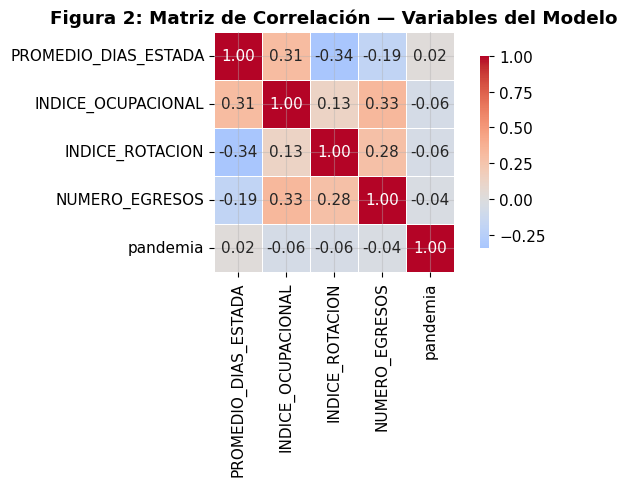

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))

vars_corr = ["PROMEDIO_DIAS_ESTADA","INDICE_OCUPACIONAL","INDICE_ROTACION","NUMERO_EGRESOS","pandemia"]
corr_matrix = df_model[vars_corr].corr().round(3)

print("Tabla 4: Matriz de correlaciones de Pearson")
print(corr_matrix.to_string())

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={"shrink": 0.8})
ax.set_title("Figura 2: Matriz de Correlación — Variables del Modelo", fontweight="bold")
plt.tight_layout()
plt.savefig("fig2_correlacion.png", dpi=150, bbox_inches="tight")
plt.show()

El índice de rotación es la variable con correlación negativa más fuerte con la estancia (r = −0.34), lo que es consistente con la hipótesis de que una mayor eficiencia en el flujo de pacientes reduce los días de hospitalización. El índice ocupacional muestra una correlación positiva moderada (r = 0.31): servicios más saturados tienden a tener estadías más largas, posiblemente por cuellos de botella en los procesos de alta. La variable pandemia presenta una correlación prácticamente nula en términos lineales (r = 0.02), aunque su efecto se captura mejor en el modelo de regresión controlando por las demás variables.

---
## 4. Test de Hipótesis

### 4.1 Formulación

| Elemento | Detalle |
|----------|---------|
| **H₀** | La mediana de estancia durante la pandemia (2020–2021) es igual a la del período pre-pandemia (2017–2019) |
| **H₁** | La mediana de estancia durante la pandemia es distinta a la del período pre-pandemia |
| **Nivel de significancia** | α = 0.05 |
| **Variable dependiente** | `PROMEDIO_DIAS_ESTADA` |
| **Variable independiente** | Período: pre-pandemia vs pandemia (categórica binaria) |
| **Test** | Mann-Whitney U bilateral |

### 4.2 Justificación del test

Se utiliza **Mann-Whitney U** en lugar del test t por tres razones:

1. La distribución de `PROMEDIO_DIAS_ESTADA` es fuertemente asimétrica (sesgo positivo), lo que viola el supuesto de normalidad del test t.
2. El test compara **medianas**, que es el estadístico de tendencia central adecuado para distribuciones asimétricas.
3. Los tamaños muestrales son distintos entre grupos (pre-pandemia n = 34.593; pandemia n = 22.339), situación que Mann-Whitney maneja correctamente.


In [8]:
pre_test = df_aguda[df_aguda["PERIODO"].isin([2017,2018,2019])]["PROMEDIO_DIAS_ESTADA"]
pan_test = df_aguda[df_aguda["PERIODO"].isin([2020,2021])      ]["PROMEDIO_DIAS_ESTADA"]

U, p_val = stats.mannwhitneyu(pre_test, pan_test, alternative="two-sided")

n1, n2 = len(pre_test), len(pan_test)
r_rb = 1 - (2 * U) / (n1 * n2)

print(f"n pre-pandemia  : {n1:,}")
print(f"n pandemia      : {n2:,}")
print(f"Mediana pre     : {pre_test.median():.3f} días")
print(f"Mediana pandemia: {pan_test.median():.3f} días")
print(f"Diferencia      : {pan_test.median()-pre_test.median():+.3f} días")
print()
print(f"Estadístico U   : {U:.0f}")
print(f"Valor p         : {'< 0.001' if p_val < 0.001 else f'{p_val:.4f}'}")
print(f"Tamaño efecto r : {r_rb:.4f}")

n pre-pandemia  : 34,593
n pandemia      : 22,339
Mediana pre     : 5.530 días
Mediana pandemia: 6.380 días
Diferencia      : +0.850 días

Estadístico U   : 359844348
Valor p         : < 0.001
Tamaño efecto r : 0.0687


### 4.3 Interpretación

El test arroja un valor p < 0.001, por lo que **se rechaza H₀** con un nivel de significancia del 5%. La mediana de días de estancia fue mayor durante la pandemia (6.38 días) que en el período previo (5.53 días), una diferencia de +0.85 días.

El tamaño del efecto (r = 0.069) es estadísticamente clasificado como pequeño, lo que indica que aunque la diferencia es real y replicable dada la magnitud muestral, la pandemia no alteró dramáticamente el promedio global de estancia. Esto es coherente con la hipótesis de que la red hospitalaria chilena mostró cierta resiliencia operativa durante la crisis, aunque a costa de una presión asistencial medible.


---
## 5. Modelo de Regresión Lineal Múltiple

### 5.1 Objetivo del modelo

El objetivo es cuantificar el efecto neto de cada variable independiente sobre `PROMEDIO_DIAS_ESTADA`, controlando simultáneamente por las demás. Esto permite separar, por ejemplo, el impacto puro de la pandemia del efecto de la mayor ocupación que también se registró en ese período.

### 5.2 Especificación

```
PROMEDIO_DIAS_ESTADA ~ INDICE_OCUPACIONAL + INDICE_ROTACION + pandemia + C(area_cat)
```

| Variable | Tipo | Justificación de inclusión |
|----------|------|---------------------------|
| `INDICE_OCUPACIONAL` | Continua | Representa la presión asistencial sobre las camas |
| `INDICE_ROTACION` | Continua | Representa la productividad y velocidad del flujo de pacientes |
| `pandemia` | Binaria (0/1) | Captura el efecto del período COVID-19 (2020–2021) |
| `C(area_cat)` | Categórica (9 niveles) | Controla la complejidad clínica — categoría de referencia: *Otras* |

La variable `TIPO_PERTENENCIA` fue descartada porque el 100% de los registros de hospitalización aguda corresponde a establecimientos públicos, lo que elimina toda varianza explicativa de esa columna.


In [9]:
formula = "PROMEDIO_DIAS_ESTADA ~ INDICE_OCUPACIONAL + INDICE_ROTACION + pandemia + C(area_cat)"
modelo  = smf.ols(formula, data=df_model).fit()

print(modelo.summary())

                             OLS Regression Results                             
Dep. Variable:     PROMEDIO_DIAS_ESTADA   R-squared:                       0.329
Model:                              OLS   Adj. R-squared:                  0.329
Method:                   Least Squares   F-statistic:                     6000.
Date:                  Sun, 10 May 2026   Prob (F-statistic):               0.00
Time:                          23:43:40   Log-Likelihood:            -5.2395e+05
No. Observations:                134835   AIC:                         1.048e+06
Df Residuals:                    134823   BIC:                         1.048e+06
Df Model:                            11                                         
Covariance Type:              nonrobust                                         
                                                              coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------

### 5.3 Tabla de resultados


In [10]:
coef_df = pd.DataFrame({
    "Coeficiente": modelo.params,
    "Error Std."  : modelo.bse,
    "t"           : modelo.tvalues,
    "p-value"     : modelo.pvalues,
    "IC 95% inf." : modelo.conf_int()[0],
    "IC 95% sup." : modelo.conf_int()[1],
}).round(4)

coef_df["Sig."] = coef_df["p-value"].apply(
    lambda p: "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "n.s."))
)

print(f"R² = {modelo.rsquared:.4f}  |  R² ajustado = {modelo.rsquared_adj:.4f}")
print(f"F  = {modelo.fvalue:.2f}     |  p-global    = {'<0.001' if modelo.f_pvalue < 0.001 else f'{modelo.f_pvalue:.4f}'}")
print(f"N  = {int(modelo.nobs):,}")
print()
print(coef_df.to_string())

R² = 0.3287  |  R² ajustado = 0.3286
F  = 6000.16     |  p-global    = <0.001
N  = 134,835

                                                         Coeficiente  Error Std.         t  p-value  IC 95% inf.  IC 95% sup. Sig.
Intercept                                                     7.8356      0.1088   72.0228      0.0       7.6223       8.0488  ***
C(area_cat)[T.Área Cuidados Intensivos Adultos ]              7.7821      0.1524   51.0592      0.0       7.4834       8.0809  ***
C(area_cat)[T.Área Cuidados Intermedios Adultos ]             3.4762      0.1395   24.9275      0.0       3.2028       3.7495  ***
C(area_cat)[T.Área Médica Adulto Cuidados Básicos ]          -6.0915      0.1111  -54.8468      0.0      -6.3092      -5.8739  ***
C(area_cat)[T.Área Médica Pediátrica Cuidados Básicos ]      -5.2841      0.1304  -40.5114      0.0      -5.5397      -5.0284  ***
C(area_cat)[T.Área Médico-Quirúrgico Cuidados Básicos ]      -7.3454      0.1135  -64.7168      0.0      -7.5679      -7.1

### 5.4 Interpretación de coeficientes


Los coeficientes del modelo se interpretan manteniendo constantes las demás variables:

**Índice Ocupacional (β = 0.158):** cada punto porcentual adicional en la ocupación de camas se asocia con 0.158 días más de estancia. Un servicio operando al 90% de ocupación tendrá, en promedio, 1.58 días más de estancia que uno al 80%. Esto refleja que la saturación genera cuellos de botella que retrasan los procesos de alta y derivación.

**Índice de Rotación (β = −1.432):** un aumento de una unidad en la rotación —es decir, un paciente adicional por cama al mes— se asocia con 1.43 días menos de estancia. Es el predictor continuo con mayor impacto en el modelo, y sugiere que la gestión del flujo de pacientes es el factor operativo más determinante para reducir los días de hospitalización.

**Pandemia (β = 0.730):** controlando por área, ocupación y rotación, los años 2020–2021 añadieron 0.73 días adicionales a la estancia promedio. Esto confirma el efecto neto del COVID-19 sobre la eficiencia hospitalaria, más allá del incremento de ocupación que también ocurrió en ese período.

**UCI Adultos vs Otras (β = 7.782):** los servicios de UCI tienen en promedio 7.78 días más de estancia que la categoría de referencia. Este coeficiente refleja la mayor complejidad clínica de los pacientes críticos y valida que el área funcional actúa correctamente como control de complejidad en el modelo.

**Médico-Quirúrgico Básico vs Otras (β = −7.345):** estos servicios presentan 7.35 días menos de estancia que la categoría de referencia. Se trata de procedimientos de menor complejidad con altas tempranas planificadas, lo que confirma que el modelo captura el espectro completo de la complejidad clínica.


### 5.5 Diagnóstico del modelo


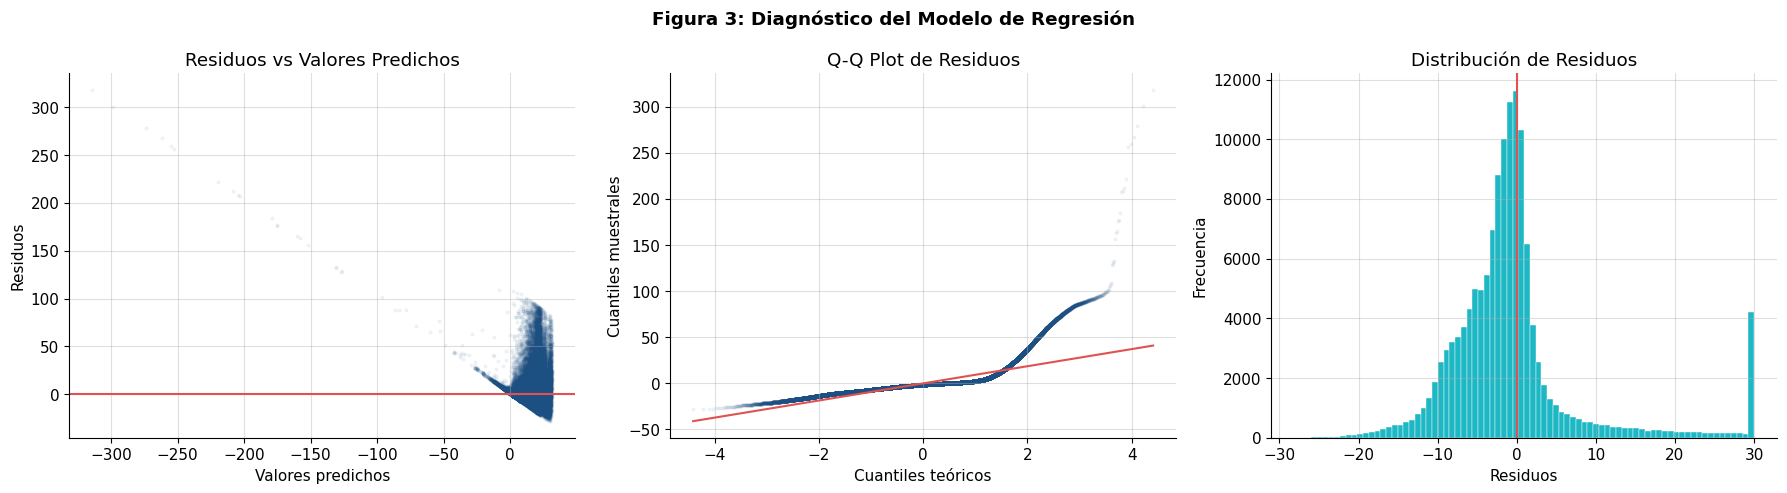

R²          = 0.3287
R² ajustado = 0.3286
F-statistic = 6000.16  (p < 0.001)
Durbin-Watson = 0.974


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Figura 3: Diagnóstico del Modelo de Regresión", fontweight="bold")

residuos  = modelo.resid
predichos = modelo.fittedvalues

ax = axes[0]
ax.scatter(predichos, residuos, alpha=0.05, s=4, color="#1C4F82")
ax.axhline(0, color="#E05252", lw=1.5)
ax.set_title("Residuos vs Valores Predichos")
ax.set_xlabel("Valores predichos"); ax.set_ylabel("Residuos")

ax = axes[1]
(osm, osr), (slope, intercept, r) = stats.probplot(residuos, dist="norm")
ax.scatter(osm, osr, alpha=0.05, s=4, color="#1C4F82")
ax.plot(osm, slope*np.array(osm)+intercept, color="#E05252", lw=1.5)
ax.set_title("Q-Q Plot de Residuos")
ax.set_xlabel("Cuantiles teóricos"); ax.set_ylabel("Cuantiles muestrales")

ax = axes[2]
ax.hist(residuos.clip(lower=-30, upper=30), bins=80, color="#1EB8C5", edgecolor="white", lw=0.3)
ax.axvline(0, color="#E05252", lw=1.5)
ax.set_title("Distribución de Residuos")
ax.set_xlabel("Residuos"); ax.set_ylabel("Frecuencia")

plt.tight_layout()
plt.savefig("fig3_diagnostico.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"R²          = {modelo.rsquared:.4f}")
print(f"R² ajustado = {modelo.rsquared_adj:.4f}")
print(f"F-statistic = {modelo.fvalue:.2f}  (p < 0.001)")
print(f"Durbin-Watson = {sm.stats.stattools.durbin_watson(residuos):.3f}")

**Capacidad explicativa:** el modelo explica el 32.9% de la varianza de la estancia (R² = 0.329). En el contexto de datos administrativos hospitalarios, donde gran parte de la variabilidad depende de factores clínicos individuales no registrados en el REM 20 (diagnóstico CIE-10, comorbilidades, severidad), este valor es sólido y consistente con la literatura de gestión sanitaria.

**Significancia global:** el estadístico F = 6.000 con p < 0.001 confirma que el modelo en su conjunto es estadísticamente significativo.

**Limitaciones detectadas en los residuos:**

- El Q-Q plot muestra colas pesadas en los extremos: los residuos no siguen una distribución normal, lo que es esperado cuando la variable dependiente es asimétrica. Con n > 100.000 el estimador OLS sigue siendo consistente por el teorema del límite central, pero los errores estándar podrían estar subestimados.
- El gráfico de residuos vs predichos sugiere heterocedasticidad: la varianza de los errores aumenta con el valor predicho, lo cual es característico de estancias hospitalarias con casos extremos. Para el avance final se explorará una transformación logarítmica de la variable dependiente.
- El valor de Durbin-Watson (≈ 0.97) indica autocorrelación positiva, esperable en datos de panel mensuales donde los registros de un mismo hospital en meses consecutivos son similares entre sí.


---
## 6. Discusión Preliminar

Los tres análisis realizados entregan resultados coherentes entre sí.

El EDA reveló que la distribución de estancia es fuertemente asimétrica, con la mayoría de los registros concentrados por debajo de los 10 días y una cola de casos complejos que eleva el promedio a 12.77 días. La diferencia entre áreas funcionales es notable: los servicios de UCI tienen estancias medianas varias veces superiores a las de cuidados básicos, lo que confirma que la complejidad clínica es un determinante estructural de la eficiencia.

El test de Mann-Whitney rechazó H₀ con p < 0.001: la estancia mediana fue 0.85 días mayor durante la pandemia. El tamaño del efecto pequeño (r = 0.069) sugiere que la red hospitalaria chilena mantuvo cierta resiliencia operativa durante 2020–2021, aunque el impacto fue estadísticamente real y medible.

El modelo de regresión cuantificó el efecto neto de cada factor. El índice de rotación resultó ser el predictor con mayor impacto (β = −1.432): gestionar el flujo de pacientes es más determinante que cualquier otro indicador operativo. La pandemia agregó 0.73 días incluso controlando por ocupación y complejidad, lo que indica que el efecto COVID-19 no se reduce a un aumento de saturación sino que refleja una mayor severidad clínica y dificultades logísticas propias del período.

Un hallazgo inesperado fue que el 100% de los registros de hospitalización aguda corresponde a establecimientos públicos, lo que elimina la posibilidad de comparar eficiencia pública versus privada en este subconjunto. Esto no se anticipó en el Avance 1 y representa una limitación del dataset para responder esa dimensión de la pregunta de investigación.

Las principales limitaciones del análisis son la ausencia de diagnóstico CIE-10, la heterocedasticidad de los residuos y la autocorrelación por la naturaleza longitudinal de los datos. Estos aspectos serán abordados en el avance final mediante transformación logarítmica e inclusión de efectos fijos por servicio de salud.


---
## 7. Próximos Pasos — Avance Final

- Realizar un análisis de varianza por Servicio de Salud (`GLOSA_SSS`) para identificar si existen brechas de eficiencia geográficamente localizadas.
- Explorar un modelo log-lineal (transformación `log(PROMEDIO_DIAS_ESTADA)`) para corregir la heterocedasticidad y mejorar el ajuste en casos de estancia larga.
- Incorporar términos de interacción entre `pandemia` y `area_cat` para evaluar si el impacto del COVID-19 fue diferenciado según tipo de servicio.
- Elaborar un análisis de series de tiempo mensual para determinar si el sistema ha retornado a los niveles de eficiencia pre-pandemia o si existen cambios estructurales permanentes.
- Ampliar la revisión bibliográfica con estudios de eficiencia hospitalaria en países latinoamericanos con sistemas similares al chileno.
